# 14-1: Panorama de los Modelos Lineales Generalizados (GLMs)

**Curso:** Modelos de Análisis Estadístico (MAE) — Universidad de los Andes  
**Docente:** Prof. Alejandra Tabares  
**Semana:** 14

## 1. El Marco GLM

Un **Modelo Lineal Generalizado** unifica una amplia clase de modelos de regresión bajo tres componentes:

### 1.1 Componente Aleatorio

La variable respuesta $Y_i$ sigue una distribución de la **familia exponencial**:

$$
f(y_i; \theta_i, \phi) = \exp\!\left[\frac{y_i\theta_i - b(\theta_i)}{a(\phi)} + c(y_i, \phi)\right]
$$

donde $\theta_i$ es el parámetro canónico (natural), $\phi$ es el parámetro de dispersión, y $a(\cdot)$, $b(\cdot)$, $c(\cdot)$ son funciones conocidas. La media es $\mu_i = b'(\theta_i)$ y la varianza es $\text{Var}(Y_i) = b''(\theta_i)\,a(\phi)$.

### 1.2 Componente Sistemático

El **predictor lineal** combina las covariables:

$$
\eta_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} = \mathbf{x}_i^\top \boldsymbol{\beta}
$$

### 1.3 Función de Enlace

La **función de enlace** $g$ conecta la media $\mu_i$ con el predictor lineal:

$$
g(\mu_i) = \eta_i \qquad \Longleftrightarrow \qquad \mu_i = g^{-1}(\eta_i)
$$

Cuando $g$ es el enlace canónico, $\theta_i = \eta_i$ y las ecuaciones de puntuación toman una forma especialmente simple.

> **Idea clave:** El modelo lineal clásico es el caso especial donde $Y_i \sim \mathcal{N}(\mu_i, \sigma^2)$ y $g$ es la identidad. Los GLMs extienden esto a respuestas no normales y no continuas manteniendo el predictor lineal.

## 2. Familias GLM Comunes

| Familia | Tipo de respuesta | Enlace canónico | Función de enlace $g(\mu)$ | Función de varianza $V(\mu)$ | Caso de uso típico |
|---|---|---|---|---|---|
| **Gaussiana** | Continua, sin límites | Identidad | $\mu$ | $1$ | Regresión clásica |
| **Binomial** | Proporciones / binaria | Logit | $\ln\!\left(\frac{\mu}{1-\mu}\right)$ | $\mu(1-\mu)$ | Resultados binarios, tasas de éxito |
| **Poisson** | Conteos no negativos | Log | $\ln(\mu)$ | $\mu$ | Conteos de eventos, eventos raros |
| **Gamma** | Continua positiva | Inverso | $1/\mu$ | $\mu^2$ | Duraciones sesgadas, costos |
| **Gaussiana Inversa** | Continua positiva | $1/\mu^2$ | $1/\mu^2$ | $\mu^3$ | Duraciones muy sesgadas |
| **Binomial Negativa** | Conteos sobredispersos | Log | $\ln(\mu)$ | $\mu + \mu^2/r$ | Datos de conteo con sobredispersión |

**Notas:**
- El *enlace canónico* es teóricamente conveniente pero no siempre óptimo en la práctica.
- Para Binomial, el probit ($\Phi^{-1}(\mu)$) y el log-log complementario ($\ln(-\ln(1-\mu))$) son alternativas comunes.
- Para Gamma, el enlace log suele preferirse al enlace inverso canónico por su interpretabilidad.

## 3. Ajuste de GLMs con `statsmodels` — Ejemplos Simulados

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 300

# Covariables compartidas
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)

# Predictor lineal verdadero
eta = 1.0 + 0.8 * x1 - 0.5 * x2

# --- Respuesta Gaussiana (enlace identidad) ---
y_gaussian = eta + np.random.normal(0, 1, n)

# --- Respuesta Binomial (enlace logit) ---
p = 1 / (1 + np.exp(-eta))
y_binomial = np.random.binomial(1, p, n)

# --- Respuesta Poisson (enlace log) ---
mu_poisson = np.exp(0.5 + 0.4 * x1 - 0.3 * x2)
y_poisson = np.random.poisson(mu_poisson, n)

# --- Respuesta Gamma (enlace log para interpretabilidad) ---
mu_gamma = np.exp(0.5 + 0.6 * x1 - 0.4 * x2)
shape_param = 3.0  # forma k; media = k/tasa => tasa = k/mu
y_gamma = np.random.gamma(shape=shape_param, scale=mu_gamma / shape_param, size=n)

df = pd.DataFrame({'x1': x1, 'x2': x2,
                   'y_gaussian': y_gaussian,
                   'y_binomial': y_binomial,
                   'y_poisson': y_poisson,
                   'y_gamma': y_gamma})
print('Dimensiones del conjunto de datos:', df.shape)
print(df.head())

Dimensiones del conjunto de datos: (300, 6)
         x1        x2  y_gaussian  y_binomial  y_poisson   y_gamma
0  0.496714 -0.828995    2.568857           1          1  2.014579
1 -0.138264 -0.560181    0.247314           0          4  1.843936
2  0.647689  0.747294    2.014110           0          3  3.763703
3  1.523030  0.610370    3.268877           1          6  4.740849
4 -0.234153 -0.020902    1.236563           1          1  0.226437


In [2]:
# ── Ajuste de los cuatro GLMs ──────────────────────────────────────────────────────────

# 1. GLM Gaussiano (equivalente a MCO)
glm_gaussian = smf.glm('y_gaussian ~ x1 + x2', data=df,
                        family=sm.families.Gaussian()).fit()

# 2. GLM Binomial (regresión logística)
glm_binomial = smf.glm('y_binomial ~ x1 + x2', data=df,
                        family=sm.families.Binomial()).fit()

# 3. GLM Poisson (enlace log)
glm_poisson = smf.glm('y_poisson ~ x1 + x2', data=df,
                       family=sm.families.Poisson()).fit()

# 4. GLM Gamma (enlace log)
glm_gamma = smf.glm('y_gamma ~ x1 + x2', data=df,
                     family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# Imprimir tablas de coeficientes
for name, model in [('Gaussiano', glm_gaussian), ('Binomial', glm_binomial),
                     ('Poisson', glm_poisson), ('Gamma', glm_gamma)]:
    print(f'\n{'='*55}')
    print(f'  GLM {name} — estimaciones de coeficientes')
    print(f'{'='*55}')
    print(model.summary2().tables[1].to_string())


  GLM Gaussiano — estimaciones de coeficientes
              Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept  1.081242  0.057680  18.745606  2.102611e-78  0.968191  1.194292
x1         0.760349  0.058736  12.945138  2.503130e-38  0.645228  0.875470
x2        -0.534090  0.060115  -8.884443  6.424196e-19 -0.651913 -0.416266

  GLM Binomial — estimaciones de coeficientes
              Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept  0.975382  0.141306  6.902608  5.105652e-12  0.698427  1.252338
x1         0.720474  0.154575  4.660991  3.146905e-06  0.417512  1.023435
x2        -0.558695  0.147114 -3.797693  1.460489e-04 -0.847034 -0.270356

  GLM Poisson — estimaciones de coeficientes
              Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
Intercept  0.481961  0.047792  10.084470  6.471330e-24  0.388290  0.575632
x1         0.450341  0.039764  11.325486  9.813305e-30  0.372406  0.528276
x2        -0.300558  0.045148  -6.6571

## 4. Cómo Elegir una Familia GLM

Seleccionar la familia GLM correcta implica tanto razonamiento sustantivo como verificaciones empíricas:

### Paso 1 — Observe la variable respuesta

| Tipo de respuesta | Primera familia candidata |
|---|---|
| Continua, aproximadamente simétrica | **Gaussiana** |
| Binaria (0/1) o proporción | **Binomial** |
| Entero no negativo (conteo) | **Poisson** |
| Continua positiva, con sesgo a la derecha | **Gamma** |
| Continua positiva, muy sesgada | **Gaussiana Inversa** |

### Paso 2 — Verifique la relación media-varianza

Grafique las medias grupales contra las varianzas grupales (o los residuos). Si la varianza crece con la media:
- Proporcionalmente → Poisson
- Como $\mu^2$ → Gamma
- Más rápido que $\mu^2$ → considere Binomial Negativa o quasi-Poisson

### Paso 3 — Compare modelos candidatos

Use el **AIC** (Criterio de Información de Akaike) para comparar modelos con la misma variable respuesta pero diferentes familias o funciones de enlace:
$$
\text{AIC} = -2\,\ell(\hat{\boldsymbol{\beta}}) + 2p
$$
Un AIC menor es mejor. No compare AIC entre diferentes transformaciones de la respuesta.

### Paso 4 — Inspeccione los residuos

Use **residuos de devianza** o **residuos de Pearson** graficados contra los valores ajustados para detectar patrones.

In [3]:
# ── Tabla de comparación AIC ───────────────────────────────────────────────────────────

# Ajustamos funciones de enlace alternativas para el modelo Gamma para ilustrar la selección por AIC
glm_gamma_inv = smf.glm('y_gamma ~ x1 + x2', data=df,
                          family=sm.families.Gamma(
                              link=sm.families.links.InversePower())).fit()
glm_gamma_id  = smf.glm('y_gamma ~ x1 + x2', data=df,
                          family=sm.families.Gamma(
                              link=sm.families.links.Identity())).fit()

aic_table = pd.DataFrame({
    'Model': [
        'Gaussian (identity)',
        'Binomial (logit)',
        'Poisson (log)',
        'Gamma (log link)',
        'Gamma (inverse link)',
        'Gamma (identity link)'
    ],
    'Response': ['y_gaussian', 'y_binomial', 'y_poisson',
                 'y_gamma', 'y_gamma', 'y_gamma'],
    'AIC': [
        glm_gaussian.aic,
        glm_binomial.aic,
        glm_poisson.aic,
        glm_gamma.aic,
        glm_gamma_inv.aic,
        glm_gamma_id.aic
    ],
    'Deviance': [
        glm_gaussian.deviance,
        glm_binomial.deviance,
        glm_poisson.deviance,
        glm_gamma.deviance,
        glm_gamma_inv.deviance,
        glm_gamma_id.deviance
    ],
    'df_resid': [
        glm_gaussian.df_resid,
        glm_binomial.df_resid,
        glm_poisson.df_resid,
        glm_gamma.df_resid,
        glm_gamma_inv.df_resid,
        glm_gamma_id.df_resid
    ]
})

aic_table['AIC'] = aic_table['AIC'].round(2)
aic_table['Deviance'] = aic_table['Deviance'].round(4)
print('\nTabla de Comparación AIC')
print('=' * 70)
print(aic_table.to_string(index=False))

# Entre los modelos Gamma, el enlace log gana (menor AIC)
gamma_aic = aic_table[aic_table['Response'] == 'y_gamma'].copy()
best = gamma_aic.loc[gamma_aic['AIC'].idxmin(), 'Model']
print(f'\nMejor enlace Gamma según AIC: {best}')


Tabla de Comparación AIC
                Model   Response     AIC  Deviance  df_resid
  Gaussian (identity) y_gaussian  853.61  296.2702       297
     Binomial (logit) y_binomial  330.95  324.9485       297
        Poisson (log)  y_poisson  960.38  349.8302       297
     Gamma (log link)    y_gamma  715.83   92.1685       297
 Gamma (inverse link)    y_gamma 1075.22  238.2770       297
Gamma (identity link)    y_gamma 1115.91  270.1365       297

Mejor enlace Gamma según AIC: Gamma (log link)


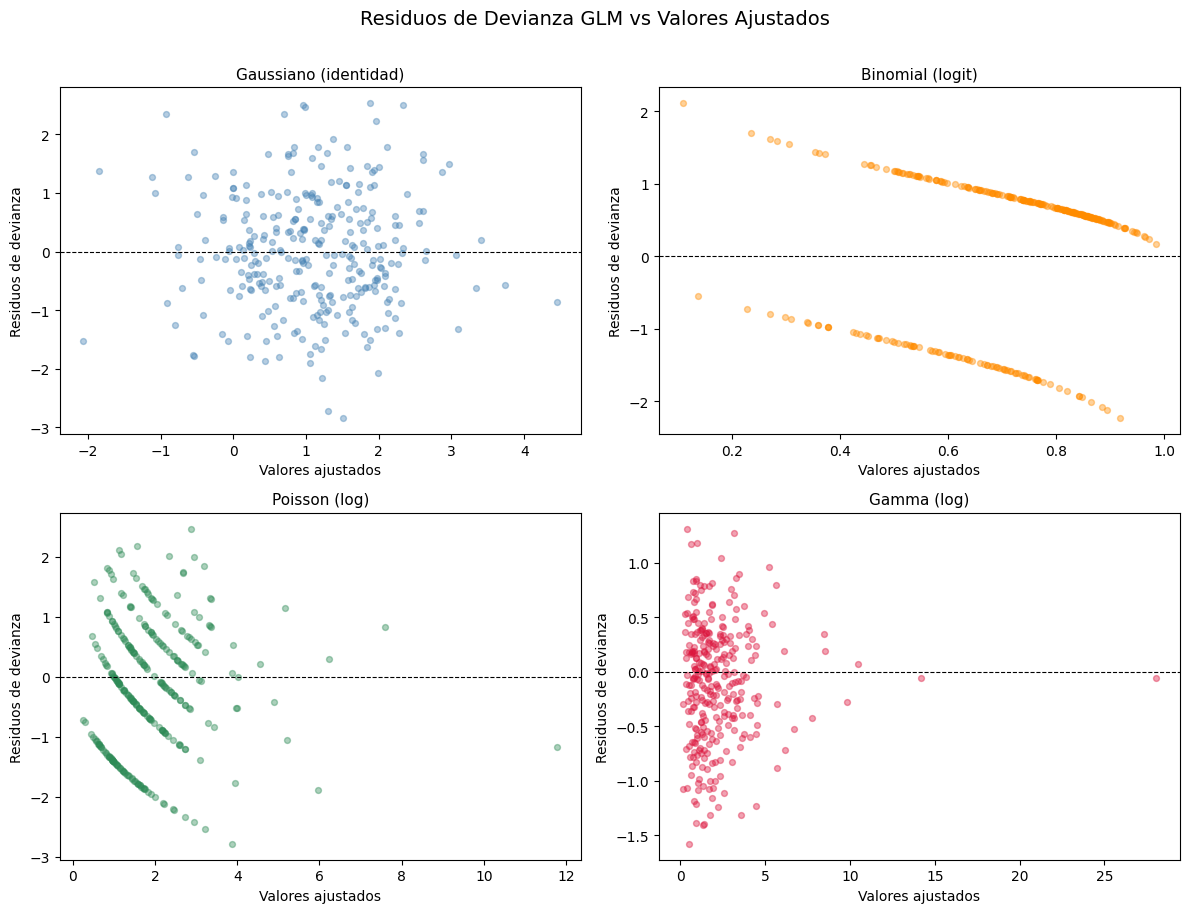

In [4]:
# ── Gráficos de residuos para diagnóstico del GLM ─────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Residuos de Devianza GLM vs Valores Ajustados', fontsize=14, y=1.01)

models_plot = [
    (glm_gaussian, 'Gaussiano (identidad)', 'steelblue'),
    (glm_binomial, 'Binomial (logit)',    'darkorange'),
    (glm_poisson,  'Poisson (log)',       'seagreen'),
    (glm_gamma,    'Gamma (log)',         'crimson'),
]

for ax, (model, title, color) in zip(axes.flatten(), models_plot):
    fitted = model.fittedvalues
    resid  = model.resid_deviance
    ax.scatter(fitted, resid, alpha=0.4, s=18, color=color)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Valores ajustados', fontsize=10)
    ax.set_ylabel('Residuos de devianza', fontsize=10)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

## 5. Devianza y Bondad de Ajuste en GLMs

### Devianza

La **devianza** generaliza la suma de cuadrados residual (SCR) a los GLMs:

$$
D = 2\left[\ell(\text{modelo saturado}) - \ell(\hat{\boldsymbol{\beta}})\right]
$$

- El **modelo saturado** tiene un parámetro por observación ($\hat{\mu}_i = y_i$), alcanzando la log-verosimilitud máxima posible.
- Para un GLM Gaussiano, $D = \text{SCR}/\sigma^2$ — idéntico a la SC residual de la prueba F clásica.
- Para Poisson: $D = 2\sum_i \left[y_i \ln(y_i/\hat{\mu}_i) - (y_i - \hat{\mu}_i)\right]$

### Devianza Nula y Residual

| Cantidad | Definición | Grados de libertad |
|---|---|---|
| **Devianza nula** | Devianza del modelo solo con intercepto | $n - 1$ |
| **Devianza residual** | Devianza del modelo ajustado | $n - p - 1$ |
| **Devianza explicada** | Nula $-$ Residual | $p$ |

### Estadístico $\chi^2$ de Pearson

$$
X^2 = \sum_{i=1}^n \frac{(y_i - \hat{\mu}_i)^2}{V(\hat{\mu}_i)}
$$

Tanto $D$ como $X^2$ siguen aproximadamente $\chi^2_{n-p-1}$ bajo el modelo — pero solo en muestras grandes y para respuestas continuas.

### Sobredispersión

En los GLMs Poisson/Binomial, el **parámetro de dispersión** $\phi$ está fijo en 1. Si $D/(n-p-1) \gg 1$, los datos exhiben **sobredispersión**. Soluciones:
- Usar **quasi-Poisson** o **quasi-Binomial** (estima $\phi$ a partir de los datos)
- Cambiar a regresión **Binomial Negativa**

### Pseudo-$R^2$

$$
R^2_{\text{McFadden}} = 1 - \frac{\ell(\hat{\boldsymbol{\beta}})}{\ell(\boldsymbol{\beta}_0)}
$$

Útil para comparaciones relativas, no como medida absoluta.